<a href="https://www.kaggle.com/code/salmamorsi/data-analysis-challenges-and-solutions?scriptVersionId=325476336" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/publisher_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/yearly_trends.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/genre_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/platform_summary.csv


#                                  LEVEL : EASY

> Challenge 1: Data Ingestion and Inspection (pandas)
>
>
> Goal: Get familiar with the layout, size, and health of your dataset.
>
>
> Task: Load the games.csv file into a pandas DataFrame. Display the first $5$ rows, find the exact total number of rows and columns, and print out a summary of the data types and non-null counts for every column.

In [9]:
df = pd.read_csv("/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv")
pd.set_option('display.max_columns', None)

df.head()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,69,6.7,34,1172,10.01,8.35,2.58,3.46,24.40,575.88,49.99,1,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,78,9.4,5,186,52.28,33.72,5.32,12.30,103.62,5056.51,59.99,1,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,76,6.6,33,363,2.90,1.48,0.75,0.91,6.04,138.60,59.99,0,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,62,7.0,28,532,6.76,3.27,0.73,2.34,13.10,36.98,0.00,0,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,62,5.6,58,1280,25.12,15.94,7.02,7.71,55.79,2148.24,69.99,1,1,0,1,0,0,0,0,0,150.8,322.3


In [10]:
df.dtypes

game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                        int64
user_score                            float64
critic_review_count                     int64
user_review_count                       int64
na_sales_million                      float64
eu_sales_million                      float64
jp_sales_million                      float64
other_sales_million                   float64
global_sales_million              

In [11]:
df.shape

(50000, 35)

In [12]:
df.isnull().sum()

game_id                               0
title                                 0
platform                              0
platform_type                         0
platform_maker                        0
platform_generation                   0
genre                                 0
year                                  0
publisher                             0
developer                             0
publisher_region                      0
publisher_tier                        0
esrb_rating                           0
metacritic_score                      0
user_score                            0
critic_review_count                   0
user_review_count                     0
na_sales_million                      0
eu_sales_million                      0
jp_sales_million                      0
other_sales_million                   0
global_sales_million                  0
estimated_revenue_million_usd         0
launch_price_usd                      0
is_sequel                             0


**Challenge 2: Conditional Filtering (pandas)**


> Goal: Extract specific subsets of data based on criteria.


>  Task: Filter the dataset to find all games that meet all of the following conditions:Released in the year $2020$ or later.Available on either the 'PlayStation 5' or 'Xbox Series X' platform.Has a Metacritic score greater than or equal to $85$.Save this subset into a new DataFrame and find out how many games qualify.

In [13]:
df2 = df[(df["year"] >= 2020) & (df["platform"].isin(["PlayStation 5", "Xbox Series X"])) 
& (df["metacritic_score"] >= 85)]

In [14]:
df2.shape

(137, 35)

> Challenge 3: Handling Missing Values (pandas)
Goal: Learn basic data cleaning techniques.

> Task: Identify which columns contain missing (NaN) values. Clean the data by:

> Filling missing values in numerical columns (like user score) with the median value of that column.

>  Filling missing values in categorical columns (like ESRB rating) with the string 'Unknown'.**

In [15]:
import seaborn as sns

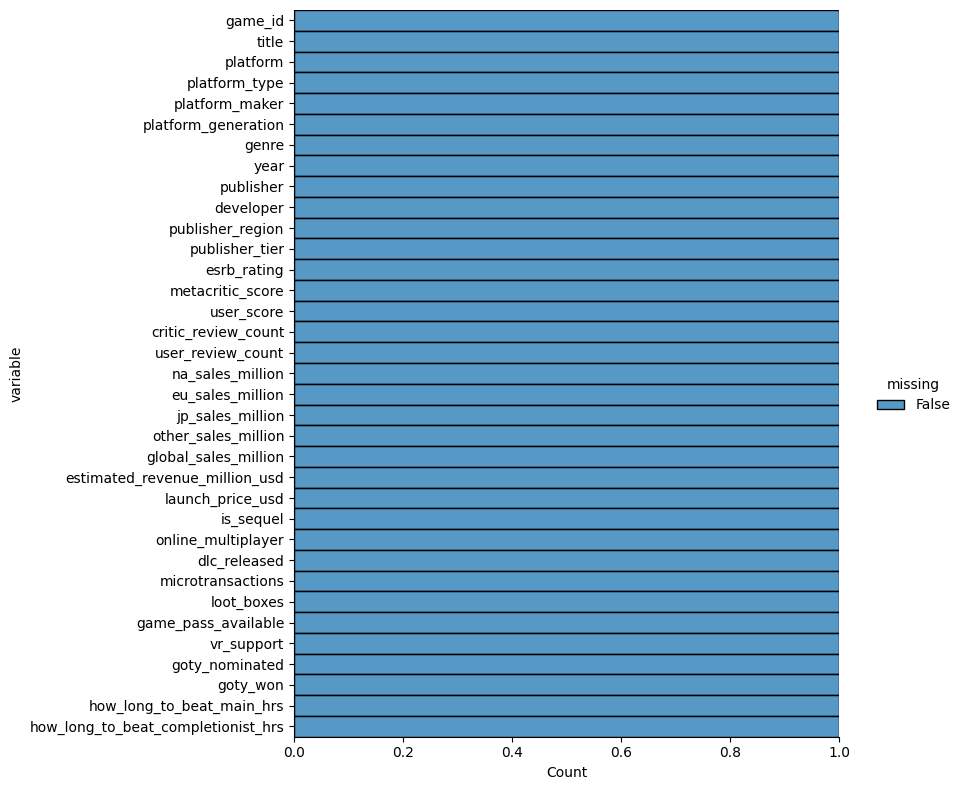

In [16]:
sns.displot(
    data=df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple='fill',
    height=8,
    aspect=1.1
)



**we have no missing values in the data set so I am skipping this one challenge**

> Challenge 4: Summary Statistics (pandas / numpy)
>
> 
> Goal: Understand the distribution of numerical features.

> Task: Compute the minimum, maximum, average (mean), and total sum for both Global sales and launch price. Use these metrics to answer: What is the highest price a game launched at in this dataset?

In [17]:
df["global_sales_million"].describe()

count    50000.000000
mean        26.034738
std         45.035430
min          0.050000
25%          5.140000
50%         12.795000
75%         29.290000
max       1494.680000
Name: global_sales_million, dtype: float64

In [18]:
df["launch_price_usd"].describe()

count    50000.000000
mean        42.028854
std         24.769804
min          0.000000
25%         19.990000
50%         39.990000
75%         59.990000
max         79.990000
Name: launch_price_usd, dtype: float64

In [19]:
# The targeted way to get exactly what you need
df[["global_sales_million", "launch_price_usd"]].agg(['min', 'max', 'mean', 'sum'])

,global_sales_million,launch_price_usd
min,5.000000e-02,0.000000e+00
max,1.494680e+03,7.999000e+01
mean,2.603474e+01,4.202885e+01
sum,1.301737e+06,2.101443e+06


In [20]:

highest_launch_price = df['launch_price_usd'].max()
print(f"The highest launch price is: ${highest_launch_price}")

The highest launch price is: $79.99


> Challenge 5: Aggregation and Grouping (pandas)
>
> 
> Goal: Analyze data across categories.
> 


> Task: Group the dataset by genre. For each genre, calculate the average Metacritic score and the total Global sales. Sort the final resulting table in descending order based on total sales so you can easily spot the highest-grossing genre.

In [21]:
result = df.groupby("genre").agg(
    average_metacritic=("metacritic_score", "mean"),
    total_global_sales=("global_sales_million", "sum")
).sort_values(by="total_global_sales", ascending=False)
result

,average_metacritic,total_global_sales
genre,,
Sports,71.239275,263838.83
Action,73.497599,208197.93
Shooter,74.042607,169891.12
Role-Playing,77.459808,108963.88
Platform,74.005024,85004.80
Racing,74.399585,82745.33
Fighting,74.942050,62525.89
Simulation,74.436442,53977.48
Adventure,76.588652,39900.59


> Challenge 6: Value Counts and Percentages (pandas)
>
> Goal: Analyze categorical frequencies.
>
> Task: Find out how many games have microtransactions (microtransactions == True or $1$). Then, calculate what percentage ($\%$) of the total $50,000$ games in the dataset include microtransactions. Do the same to find the distribution of ESRB rating types.

In [22]:
df["microtransactions"]

0        0
1        1
2        0
3        1
4        1
        ..
49995    0
49996    0
49997    0
49998    1
49999    1
Name: microtransactions, Length: 50000, dtype: int64

In [23]:
filtered_df = df.query("microtransactions ==1")
filtered_df.shape

(15549, 35)

In [24]:
# Shortcut to get percentages directly
df['microtransactions'].value_counts(normalize=True) * 100

microtransactions
0    68.902
1    31.098
Name: proportion, dtype: float64


>  Challenge 7: Feature Engineering (pandas)
> 
> Goal: Derive new insights by creating columns.
> 
> Task: Create a new column named NA_Sales_Share. This column should represent the proportion of global sales that came from North America (calculated as NA sales divided by Global sales). Find the title of the game that has the highest reliance on the North American market.

In [25]:
import numpy as np

In [26]:
# 1. Group by game title and sum up the raw sales figures first
grouped_games = df.groupby('title')[['na_sales_million', 'global_sales_million']].sum()

# 2. Calculate the true share on the total combined sales
grouped_games['Total_NA_Share'] = grouped_games['na_sales_million'] / grouped_games['global_sales_million']

# 3. Sort by the true share and grab the top game
top_game_NA = grouped_games['Total_NA_Share'].sort_values(ascending=False)

# Get the name of the #1 game
print(top_game_NA.index[0])

The Elder Scrolls IX: The Fallen


> Challenge 8: Categorical Visualizations (matplotlib / seaborn)
>
> Goal: Present categorical data visually.
>
>
> Task: Find the top $10$ publishers based on total Global sales. Create a horizontal or vertical bar chart showing these top $10$ publishers and their sales. Give your chart a title, label your axes clearly, and make sure the publisher names do not overlap.

In [27]:
import matplotlib.pyplot as plt

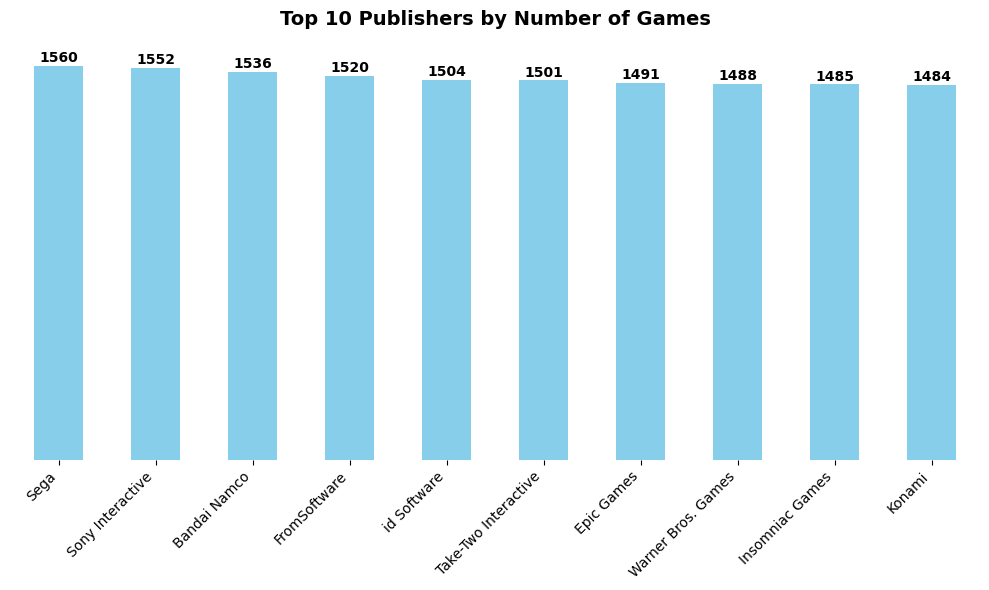

In [28]:
plt.figure(figsize=(10, 6))

top_10_publishers = df['publisher'].value_counts().head(10)
top_10_publishers.plot(kind='bar', color='skyblue')


for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.gca().get_yaxis().set_visible(False)



for i, v in enumerate(top_10_publishers):
    plt.text(
        x=i,           # The horizontal position on the chart
        y=v + 2,       # The vertical position (slightly above the top of the bar)
        s=str(int(v)), # The text label to display (converted to integer)
        ha='center',   # Center the text horizontally over the bar
        va='bottom',   # Align the bottom of the text string to the coordinate
        fontsize=10,
        fontweight='bold',
        color='black'
    )
plt.title('Top 10 Publishers by Number of Games', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Games', fontsize=12, labelpad=10)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

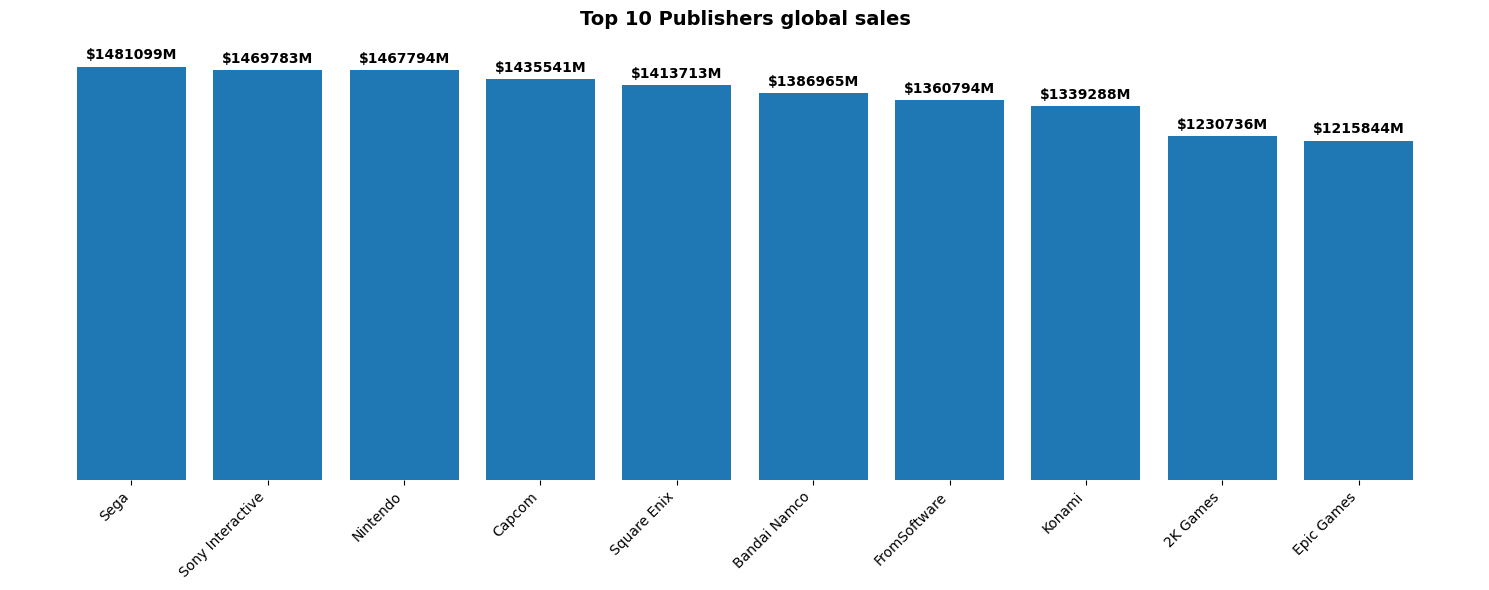

In [29]:
plt.figure(figsize=(15, 6))

top_10_sales = df.groupby('publisher')['estimated_revenue_million_usd'].sum().sort_values(ascending=False).head(10)

plt.bar(x =top_10_sales.index , height = top_10_sales.values)


for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)


plt.gca().get_yaxis().set_visible(False)


for i, v in enumerate(top_10_sales):
    plt.text(
        x=i,           
        y=v + (top_10_sales.max() * 0.01), # Dynamic padding: adds 1% of max value above the bar
        s=f"${int(v)}M",                   # Formats it nicely as currency (e.g., $150M)
        ha='center',   
        va='bottom',   
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.title('Top 10 Publishers global sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Challenge 9: Distribution Visualizations (matplotlib / seaborn)
>
> 
> Goal: Visualize the spread of a continuous variable.

> Task: Create a histogram or a Kernel Density Estimate (KDE) plot showing the distribution of Metacritic score. Add a vertical line representing the mean score of the dataset to see if the scores skew positive or negative.

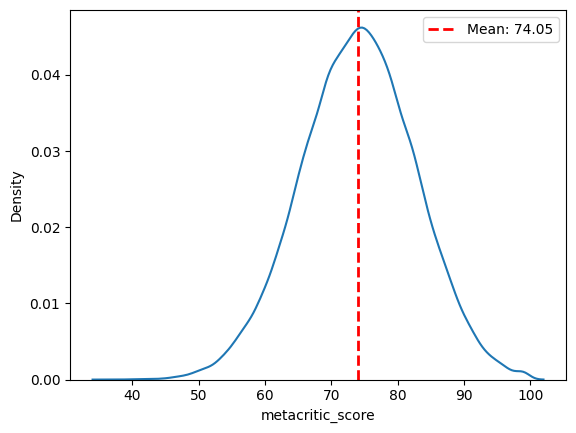

In [30]:
sns.kdeplot(data = df , x="metacritic_score")

mean_val = np.mean(df["metacritic_score"])
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.legend()

plt.show()


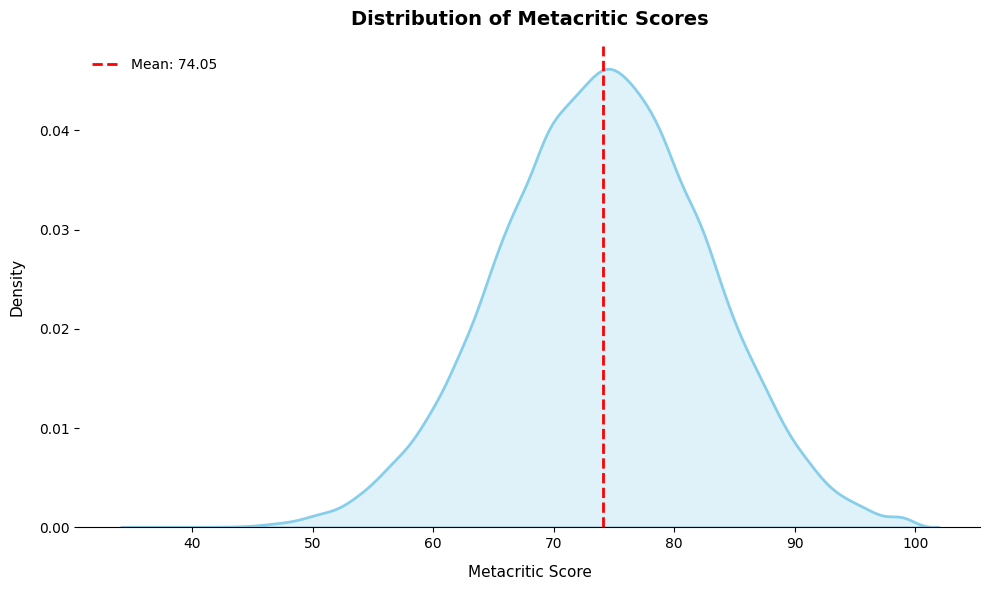

In [31]:
plt.figure(figsize=(10, 6))

# 1. Plot the distribution curve
sns.kdeplot(data=df, x="metacritic_score", fill=True, color="skyblue", linewidth=2)

# 2. Calculate the mean safely using pandas (ignores missing values)
mean_val = df["metacritic_score"].mean()

# 3. Add the vertical mean line
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')

# 4. Clean up the borders to match your design style
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Clean up typography and spacing
plt.title('Distribution of Metacritic Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Metacritic Score', fontsize=11, labelpad=10)
plt.ylabel('Density', fontsize=11, labelpad=10)
plt.legend(frameon=False, loc='upper left') # Removes the box outline around the legend

plt.tight_layout()
plt.show()

> Challenge 10: Relationship and Correlation Analysis (pandas + seaborn)
>
> 
> Goal: Explore how variables interact with one another.

> Task: Select the following four columns: Metacritic score, user score, Global sales, and estimated revenue. Compute the correlation matrix between them. Then, use seaborn to generate a annotated heatmap of this matrix to visually identify which variables have the strongest relationship.

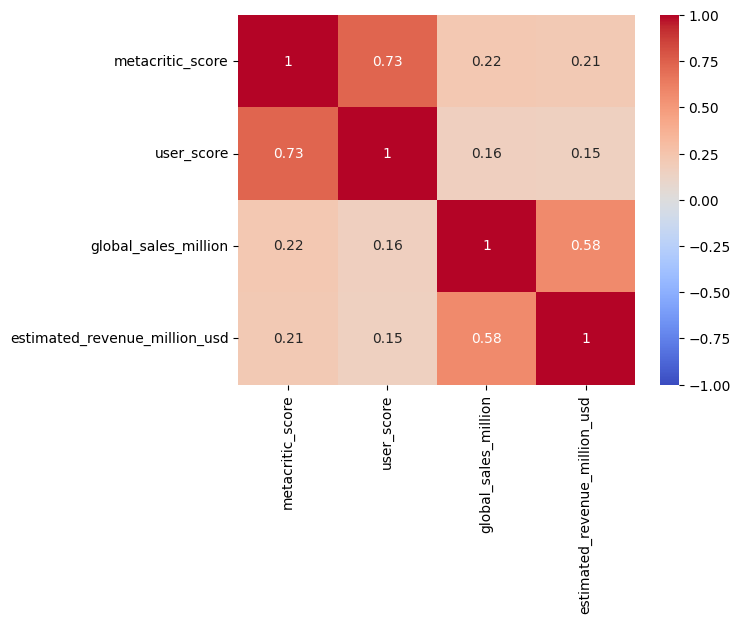

In [32]:
selected_columns = df[["metacritic_score","user_score","global_sales_million","estimated_revenue_million_usd"]]

matrix = selected_columns.corr()

sns.heatmap(matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

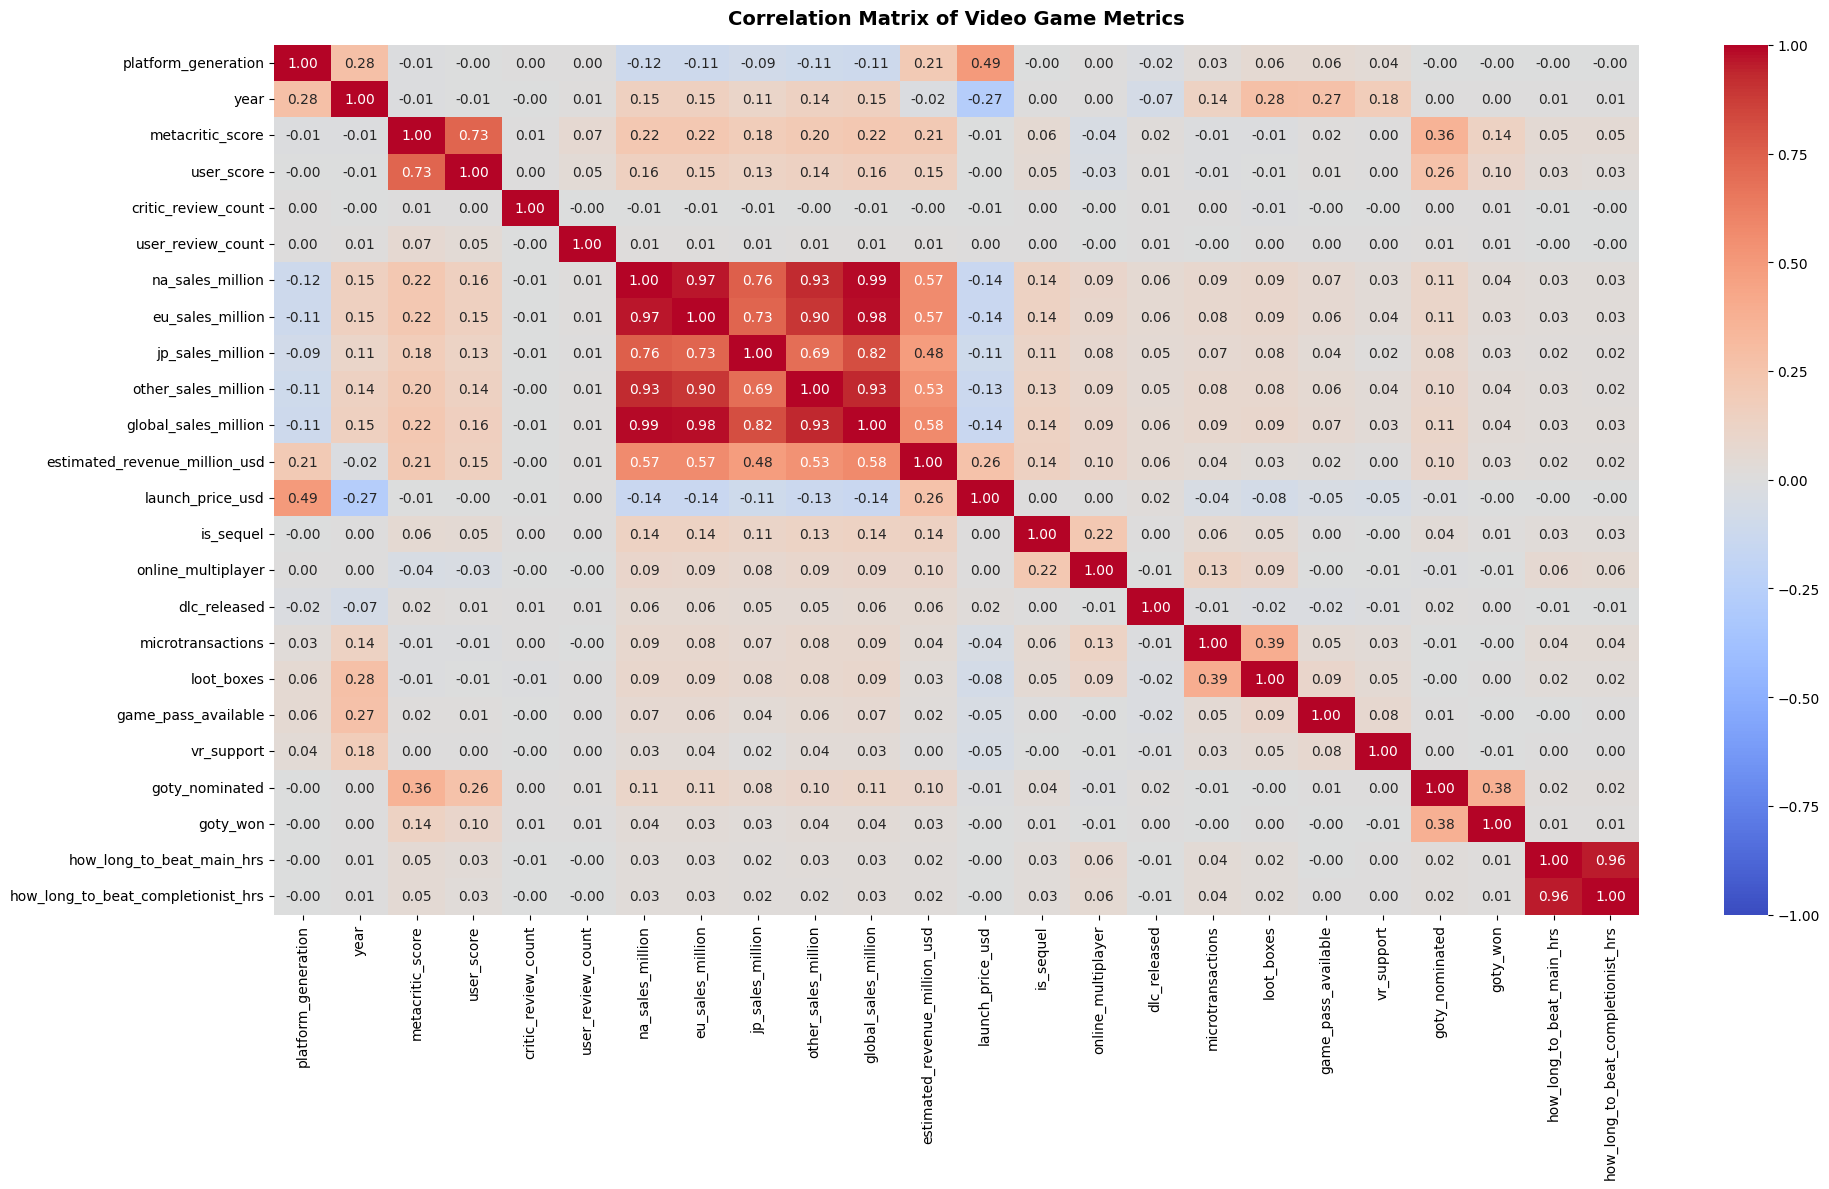

In [33]:
# Create the correlation matrix safely by filtering for numbers only
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot your exact heatmap code
plt.figure(figsize=(20, 12)) # Added a bit of extra space for readability
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Video Game Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# LEVEL : Medium

> Challenge 11: Multi-Platform Dominance
Some games are massive hits across multiple consoles, while others are platform exclusives.

> Task: Find the top 5 games that appear on the highest number of unique platforms in the dataset.

> Hint: You'll want to use .groupby() combined with the .nunique() aggregation function.

In [34]:
df["platform"].value_counts()

platform
PC                   6305
NES                  3045
Mobile (iOS)         2622
Mobile (Android)     2483
Browser              2455
Game Boy             2107
SNES                 1906
Nintendo Switch      1737
PlayStation          1727
Atari 2600           1607
Sega Genesis         1555
PlayStation 2        1540
PlayStation 4        1492
PlayStation 3        1305
Xbox Series X/S      1300
Xbox 360             1289
Nintendo 3DS         1263
Nintendo DS          1260
PlayStation 5        1223
PSP                  1130
PlayStation Vita     1101
Game Boy Advance     1094
Xbox One             1043
Xbox                  991
Wii                   887
Nintendo 64           878
GameCube              796
Stadia                795
Game Boy Color        750
Sega Saturn           724
Wii U                 689
Dreamcast             498
Nintendo Switch 2     403
Name: count, dtype: int64

In [35]:
top_5games =df.groupby('title')['platform'].nunique().sort_values(ascending=False).head(5)
top_5games

title
MLB The Show 2026    33
Madden NFL 2024      33
UFC 3                33
Overwatch 5          33
UFC 4                33
Name: platform, dtype: int64

> Challenge 12: The Critical Disconnect
Sometimes critics love a game, but the audience completely hates it.

> Task: Create a new column called score_diff which calculates the absolute difference between metacritic_score and user_score (make sure both scores are scaled to the same range first, e.g., both out of 100 or both out of 10!). Find the top 3 games with the biggest disconnect between critics and players.

In [36]:
df.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs'],
      dtype='object')

In [37]:
df["metacritic_score"]

0        69
1        78
2        76
3        62
4        62
         ..
49995    65
49996    70
49997    80
49998    70
49999    68
Name: metacritic_score, Length: 50000, dtype: int64

In [38]:
# the user_score should be multiplied by 10 to match the metacritic_score or we can divid the metacritic_score by 10
df["user_score"]

0        6.7
1        9.4
2        6.6
3        7.0
4        5.6
        ... 
49995    7.3
49996    7.3
49997    8.1
49998    6.3
49999    6.5
Name: user_score, Length: 50000, dtype: float64

In [39]:
df["score_diff"]= abs(df["metacritic_score"] -df["user_score"]*10)

In [40]:
biggest3differences = df.sort_values(by="score_diff", ascending=False).head(3)

In [41]:
print(biggest3differences[["title", "metacritic_score", "user_score", "score_diff"]])

                    title  metacritic_score  user_score  score_diff
26405     Valorant Legacy                87         5.7        30.0
32292         Titanfall 6                83         5.3        30.0
13903  Super Mario Legend                71         4.2        29.0


> Challenge 13: Segmenting by Release Era
Let's see how game characteristics changed over time.

> Task: Create a new categorical column called era using pd.cut() or custom logic based on the release year:

> 'Retro' (Before 2000)

> 'Modern Classic' (2000–2010)

> 'Next Gen' (2011–Present)

> Then, calculate the average global sales for each era to see which time period was the most lucrative.

In [42]:
df["year"].min()

1985

In [43]:
df["year"].max()

2026

In [44]:
gaming_eras = {
    "The 8-Bit & 16-Bit Era " :1995,     #1985-1995
    "The 3D Era" :2005,             #1996-2005
    "The Online & HD Era ":2014,   #2006-2014
    "The Modern & UH3D Era":2026   #2015- present
}

In [45]:
gaming_eras.values()

dict_values([1995, 2005, 2014, 2026])

In [46]:
gaming_eras.keys()

dict_keys(['The 8-Bit & 16-Bit Era ', 'The 3D Era', 'The Online & HD Era ', 'The Modern & UH3D Era'])

In [47]:
df["era"] = pd.cut(df["year"], bins =[1985] +list(gaming_eras.values()) , labels = list(gaming_eras.keys()))

In [48]:
df[["year","era"] ]

,year,era
0,1990,The 8-Bit & 16-Bit Era
1,2004,The 3D Era
2,1988,The 8-Bit & 16-Bit Era
3,2017,The Modern & UH3D Era
4,1999,The 3D Era
...,...,...
49995,2002,The 3D Era
49996,2001,The 3D Era
49997,2014,The Online & HD Era
49998,2021,The Modern & UH3D Era


> Challenge 14: Filtering the Heavy Hitters
We want to look at niche publishers vs. industry titans.

> Task: Filter your DataFrame to keep only publishers who have released more than 50 games in total. Save this as a new DataFrame called df_major_publishers.

> Hint: Look into using .groupby().filter().

In [49]:
result = df.groupby('publisher').filter(lambda x: len(x) > 50)
print(result['publisher'].unique())

['CD Projekt' 'Ubisoft' 'Microsoft Studios' 'InXile Entertainment'
 'Naughty Dog' '2K Games' 'Activision Blizzard' 'Sega' 'Humble Games'
 'Square Enix' 'Bethesda Softworks' 'Team17' 'Rockstar Games'
 'Devolver Digital' 'Nintendo' 'Take-Two Interactive'
 'Remedy Entertainment' 'Epic Games' 'Warner Bros. Games'
 'Supergiant Games' 'Valve' 'Deep Silver' 'Konami' 'id Software'
 'FromSoftware' 'ConcernedApe' '505 Games' 'Capcom' 'Sony Interactive'
 'Ghost Ship Games' 'Larian Studios' 'Toby Fox' 'Insomniac Games'
 'Bandai Namco' 'Electronic Arts' 'Chucklefish' 'Other' 'Double Fine'
 'tinyBuild' 'Annapurna Interactive' 'Klei Entertainment' 'Bungie'
 'THQ Nordic' 'Unknown Worlds' 'Focus Entertainment' 'Coffee Stain'
 'Obsidian Entertainment' 'Paradox Interactive' 'Motion Twin' 'Raw Fury'
 'Nomada Studio']


> Challenge 15: The "All-Star" Publishers
Let's find publishers who consistently pump out high-quality games, rather than just getting lucky once.

> Task: Group the data by publisher and calculate two things at once: the count of games they made and the median Metacritic score. Filter for publishers with at least 10 games, and sort them by the highest median score.

> Hint: Use .agg(['count', 'median']).

In [50]:
publishers_info = df.groupby("publisher").agg(
    game_count=("title", "count"),
    median_score=("metacritic_score", "median")
)
filtered_publishers = publishers_info[publishers_info["game_count"] >= 10]

filtered_publishers.sort_values(by="median_score", ascending=False).head(10)

,game_count,median_score
publisher,,
2K Games,1467,76.0
Activision Blizzard,1435,76.0
Bandai Namco,1536,76.0
Capcom,1456,76.0
Bethesda Softworks,1467,76.0
Bungie,1439,76.0
CD Projekt,1417,76.0
Electronic Arts,1478,76.0
Epic Games,1491,76.0


> Challenge 16: The Sales Outlier 

> Are global sales driven by a few massive hits, or do most games perform similarly?

> Task: Create a Box Plot of global_sales_million split across different game genres.

> Visualization Goal: Clean up the chart by removing the top/right spines, turning off the y-axis grid lines, and giving each genre a unique color palette.

In [51]:
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings


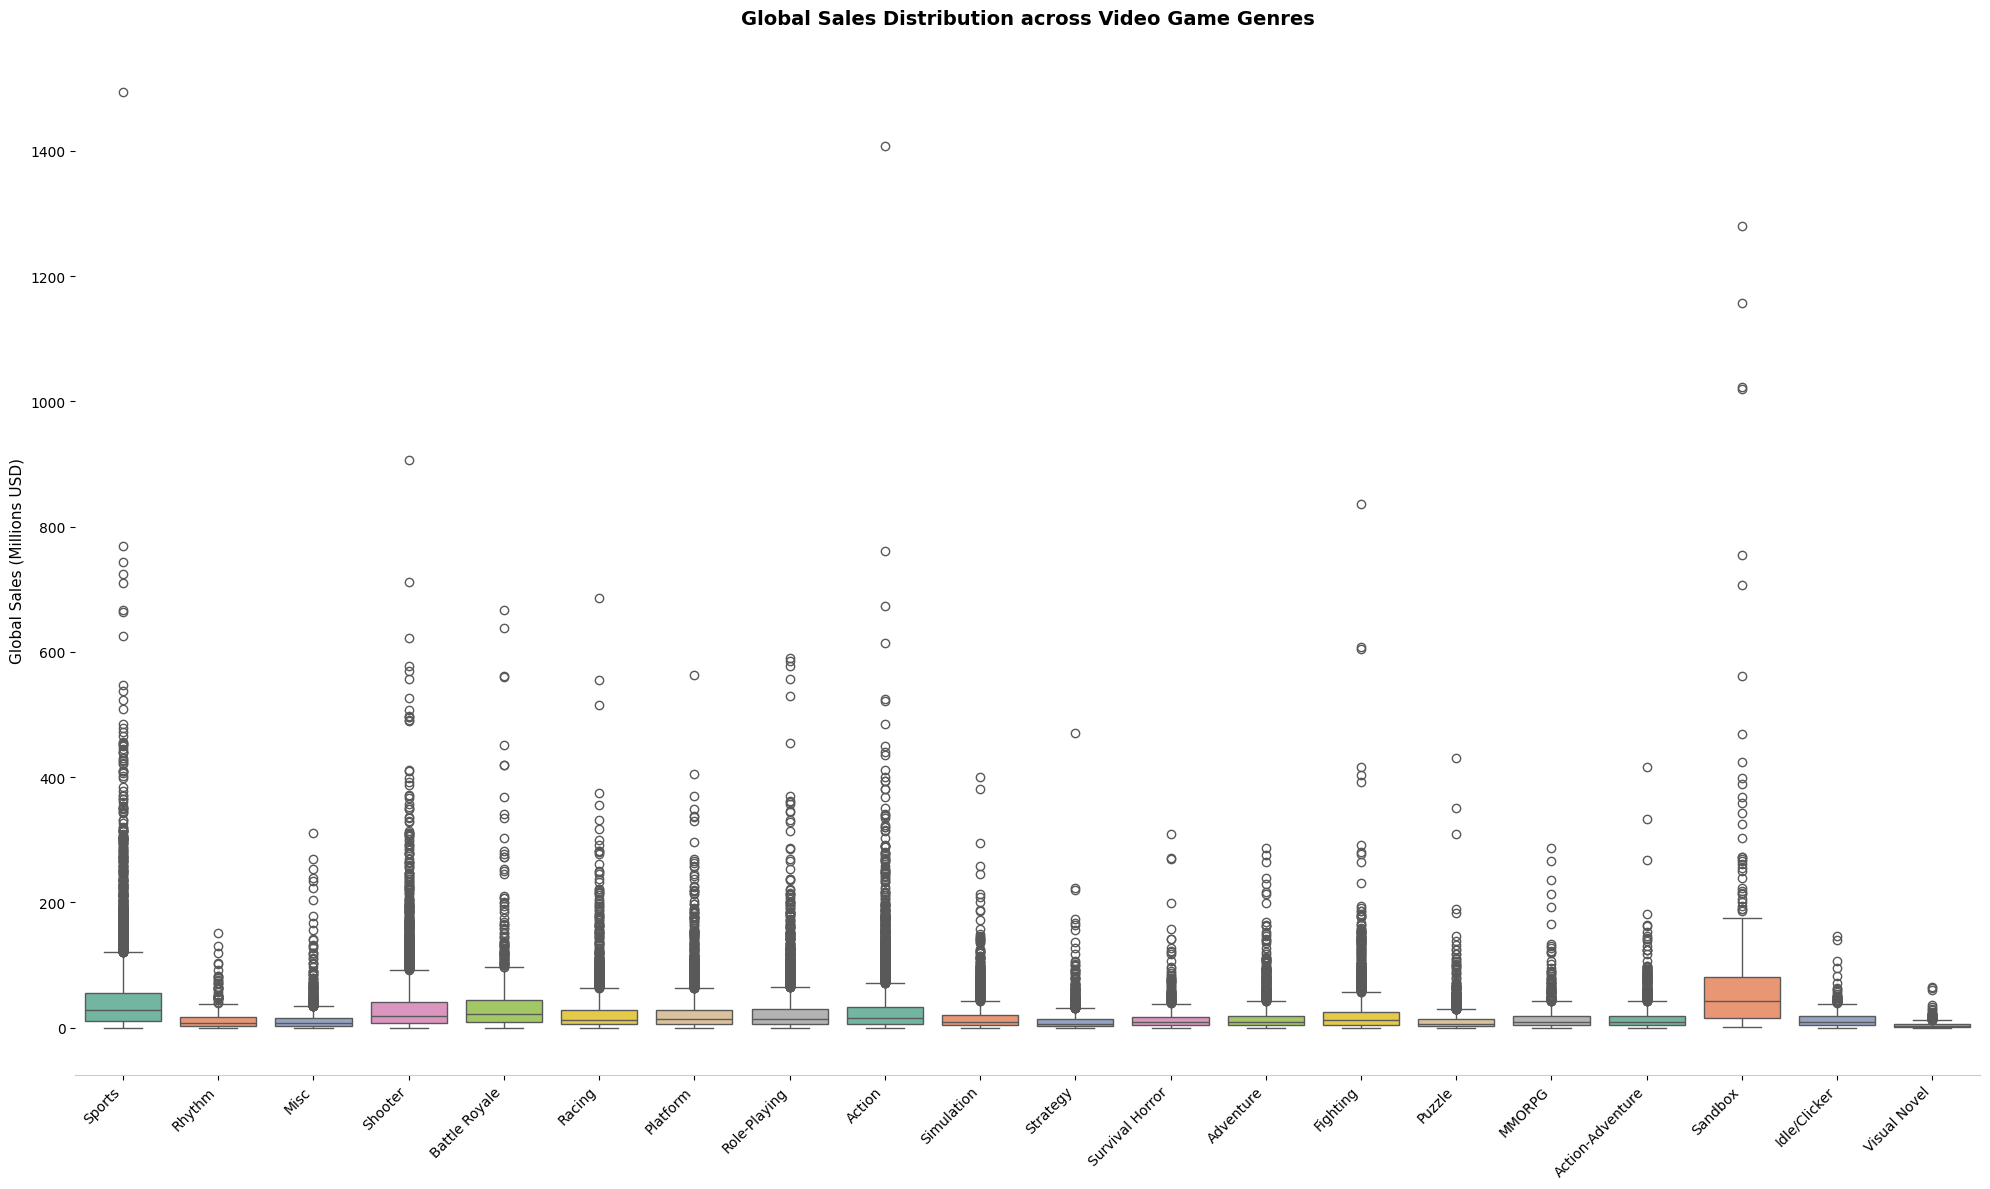

In [52]:
plt.figure(figsize=(20, 12))

# Use seaborn to split global sales by genre effortlessly
ax = sns.boxplot(
    data=df, 
    x="genre", 
    y="global_sales_million", 
    palette="Set2"  # Gives each genre a unique color palette
)

# Clean up the chart borders
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Keep the bottom spine but make it a subtle color
ax.spines['bottom'].set_color('#cccccc')

# Turn off the y-axis grid lines (Challenge Goal)
ax.yaxis.grid(False) 
ax.xaxis.grid(False)

# Styling typography
plt.title('Global Sales Distribution across Video Game Genres', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('') # Drop the redundant 'genre' label
plt.ylabel('Global Sales (Millions USD)', fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

> Challenge 17: Completionist Efficiency (Value for Money)
Let's find out which genres offer the most gameplay hours per dollar spent.

> Task: Calculate a new feature called hours_per_dollar using hours to beat (completionist) and price (or estimated revenue/cost metrics if price isn't directly available). Group by genre and create a Horizontal Bar Chart showing the average value for money per genre, sorted from highest to lowest. Annotate the bars with the values!

how_long_to_beat_completionist_hrs


estimated_revenue_million_usd


In [53]:
hours_per_value = df.groupby("genre").agg(
    AVGmoney = ("estimated_revenue_million_usd" , "mean"),
    AVGhours = ("how_long_to_beat_completionist_hrs" , "mean")
).sort_values(by = "AVGmoney" ,ascending = True)

In [54]:
hours_per_value

,AVGmoney,AVGhours
genre,,
Visual Novel,112.967598,40.881930
Puzzle,284.199064,28.238042
Strategy,305.469989,123.283055
Misc,327.793296,42.628376
Survival Horror,381.777594,34.970188
Rhythm,388.246957,42.999348
Idle/Clicker,390.198467,41.940000
Action-Adventure,397.806096,42.376272
Adventure,417.545215,41.403421


<BarContainer object of 20 artists>

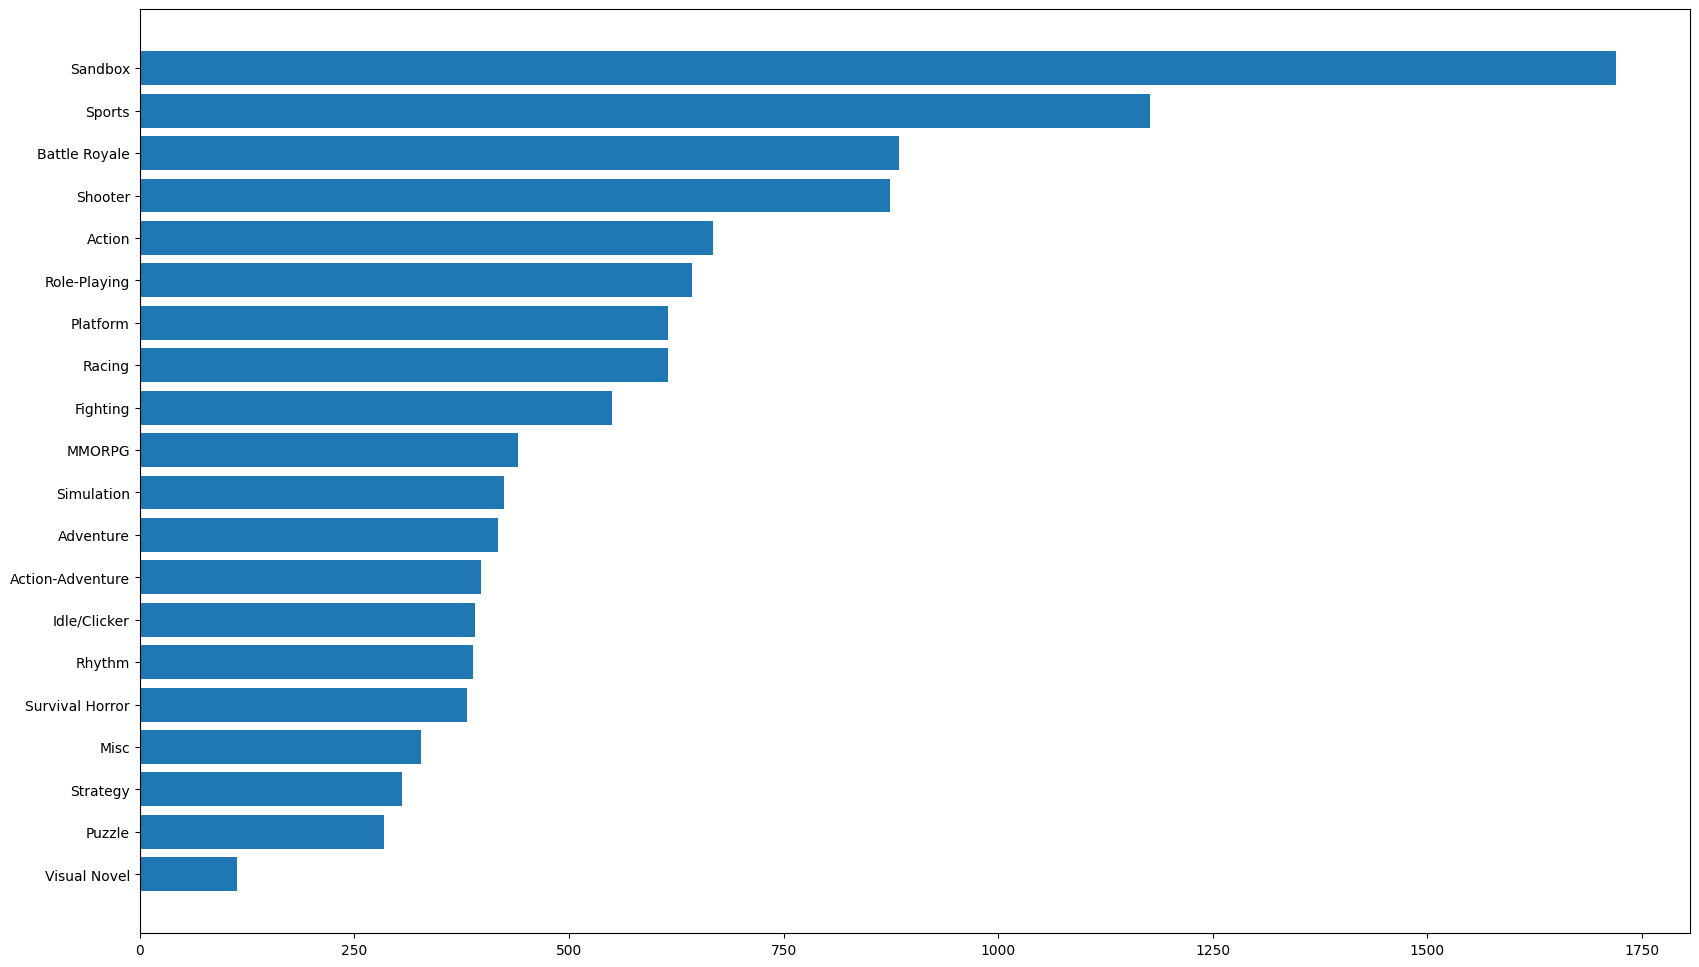

In [55]:
plt.figure(figsize=(20, 12))
plt.barh(hours_per_value.index,hours_per_value["AVGmoney"])

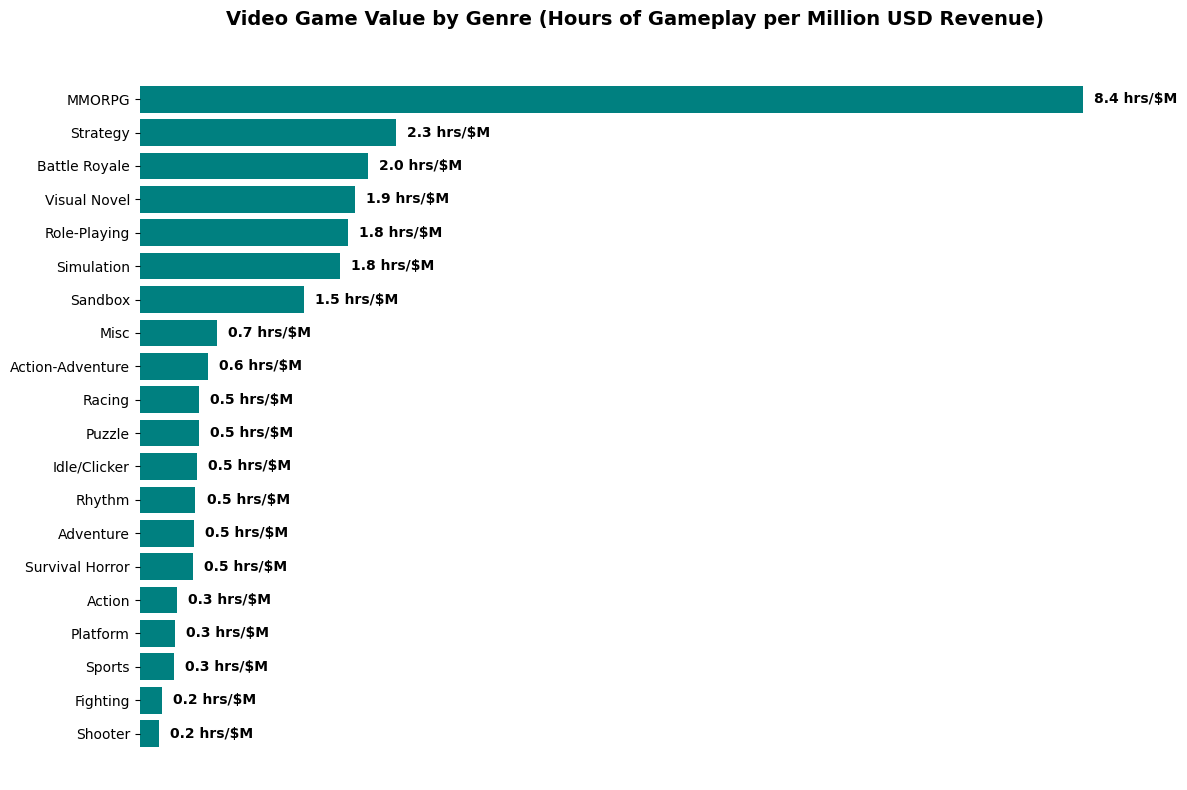

In [56]:


# 1. Calculate row-level efficiency
df["hours_per_revenue"] = df["how_long_to_beat_completionist_hrs"] / df["estimated_revenue_million_usd"]

# 2. CRITICAL FIX: Keep only rows with valid, finite numbers (removes NaN and Inf)
df_clean = df[np.isfinite(df["hours_per_revenue"])]

# 3. Group by genre using the cleaned data
genre_efficiency = df_clean.groupby("genre")["hours_per_revenue"].mean().sort_values(ascending=True)

# 4. Setup the horizontal chart
plt.figure(figsize=(12, 8))
ax = plt.gca()
bars = ax.barh(genre_efficiency.index, genre_efficiency.values, color='teal')

# 5. Clean styling
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.get_xaxis().set_visible(False) 

# 6. Add Annotations
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        text=f"{width:.1f} hrs/$M",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0),                  
        textcoords="offset points",
        va='center',                    
        ha='left',                      
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.title('Video Game Value by Genre (Hours of Gameplay per Million USD Revenue)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

> Challenge 18: Title Length vs. Popularity
Does a short, snappy game title sell better than a super long one?

> Task: Create a new column called title_length that counts the number of characters in the game's title. Then, calculate the correlation coefficient between title_length and global_sales_million. Is there any meaningful relationship?

In [57]:
df["title_length"] = df["title"].str.len()

df["title_length"].corr(df["global_sales_million"])

np.float64(-0.09287093667656113)

*as we can see here there is no correlation at all*

> Challenge 19: Finding Specific Keywords
Let's see how many games in your dataset belong to major recurring trends or spin-offs.

> Task: Filter the dataset to find all games that contain the word "Edition", "Remaster", or "Remake" in their title (case-insensitive). What percentage of the total dataset do these updated releases represent?

> Hint: Check out the .str.contains() method with the case=False argument.

In [58]:
words = ['edition', 'remaster', 'remake']

regex_pattern = '|'.join(words)

filtered_df = df[df['title'].str.contains(regex_pattern, case=False, na=False)]

In [59]:
filtered_df

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,score_diff,era,hours_per_revenue,title_length
26,G000027,Fall Guys Remastered,PC,PC,Various,0,Battle Royale,2022,Supergiant Games,Warner Bros. Games,USA,Indie,E,81,8.7,25,177,5.95,3.98,1.22,1.69,12.84,308.42,29.99,0,1,1,1,1,0,0,0,0,82.0,184.8,6.0,The Modern & UH3D Era,0.599183,20
45,G000046,Doom Remastered,Xbox One,Console,Microsoft,8,Action,2020,Capcom,Bethesda Softworks,Japan,AAA,M,66,6.1,47,55,11.26,6.19,4.74,1.27,23.46,835.49,79.99,0,0,1,0,0,0,0,0,0,11.2,31.3,5.0,The Modern & UH3D Era,0.037463,15
113,G000114,Wipeout Remastered,PlayStation 4,Console,Sony,8,Racing,2016,Valve,Raw Fury,USA,AAA,T,83,9.2,6,133,15.32,9.84,1.21,2.43,28.80,1335.01,69.99,0,0,0,0,0,0,0,0,0,17.1,48.3,9.0,The Modern & UH3D Era,0.036180,18
155,G000156,Oxenfree Remastered,PC,PC,Various,0,Adventure,2007,Bungie,Bungie,USA,AAA,E,77,7.6,6,69,1.23,0.77,0.33,0.26,2.59,42.29,59.99,0,1,0,0,0,0,0,0,0,18.4,54.4,1.0,The Online & HD Era,1.286356,19
208,G000209,Doom Remastered,NES,Console,Nintendo,3,Action,2003,Nintendo,Paradox Interactive,Japan,AAA,E,72,8.0,128,277,5.88,2.47,2.85,2.33,13.53,423.19,79.99,0,0,0,1,0,0,0,0,0,9.4,32.9,8.0,The 3D Era,0.077743,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49725,G049726,Valorant Remastered,PC,PC,Various,0,Shooter,1990,Sega,Sega,Japan,AAA,E,69,6.1,68,248,13.56,11.28,4.31,4.32,33.47,601.76,59.99,0,1,1,0,0,0,0,0,0,6.2,28.6,8.0,The 8-Bit & 16-Bit Era,0.047527,19
49846,G049847,Counter-Strike Remastered,Nintendo Switch,Hybrid,Nintendo,9,Shooter,2023,Bungie,Bungie,USA,AAA,T,88,8.8,16,334,10.07,8.79,1.96,1.40,22.22,614.43,49.99,0,1,0,1,1,0,0,0,0,8.6,23.1,0.0,The Modern & UH3D Era,0.037596,25
49855,G049856,Roblox Remastered,PC,PC,Various,0,Sandbox,1996,Ubisoft,Ubisoft,France,AAA,E,91,8.3,71,526,4.54,3.96,0.54,1.06,10.10,250.01,19.99,0,0,1,0,0,0,0,1,0,153.7,607.9,8.0,The 3D Era,2.431503,17
49881,G049882,Wipeout Remastered,PC,PC,Various,0,Racing,1998,Epic Games,Epic Games,USA,AAA,T,86,9.0,15,34,9.40,5.77,0.67,2.37,18.21,353.03,29.99,0,1,0,0,0,0,0,1,0,18.2,39.5,4.0,The 3D Era,0.111889,18


In [60]:
percentage = (len(filtered_df) / len(df)) * 100

print(f"Percentage of updated releases: {percentage:.2f}%")

Percentage of updated releases: 1.83%


> Challenge 20: The Ultimate Pivot Table
Let's create a comprehensive summary grid that crosses two categorical variables.

> Task: Build a pivot table where the rows are the game genres, the columns are the publisher regions (e.g., USA, Japan, Europe), and the values inside the grid show the average global sales.

> Hint: Use pd.pivot_table(). Fill any missing NaN values in the resulting grid with 0

In [61]:
df.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'score_diff', 'era', 'hours_per_revenue', 'title_length'],
      dtype='object')

In [62]:
pivot = df.pivot_table(index="genre", columns="publisher_region", values="global_sales_million", aggfunc="mean" , fill_value =0)
pivot.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.2f}")

publisher_region,Austria,Belgium,Canada,Denmark,Finland,France,Germany,Italy,Japan,Poland,Spain,Sweden,UK,USA,Various
genre,,,,,,,,,,,,,,,
Action,7.94,8.25,3.78,4.10,8.61,20.15,9.10,9.37,38.85,35.61,4.74,6.36,5.98,29.42,5.10
Action-Adventure,4.29,5.91,1.89,2.18,4.66,14.45,4.07,3.84,24.10,19.11,2.03,3.31,4.21,15.81,2.51
Adventure,4.76,4.48,2.88,2.01,4.93,12.88,4.80,3.85,23.47,17.11,4.28,2.96,2.87,17.75,2.58
Battle Royale,10.09,8.86,6.19,1.82,11.32,20.81,8.17,17.79,60.51,42.04,3.68,6.12,7.40,40.43,6.07
Fighting,5.44,6.47,3.58,4.10,8.63,20.49,5.66,7.04,33.37,29.08,3.74,4.64,5.55,22.76,4.18
Idle/Clicker,7.69,4.26,0.00,6.27,4.70,10.31,3.84,3.05,22.86,18.74,2.98,3.59,3.76,13.99,1.19
MMORPG,5.69,4.29,1.16,1.71,3.44,17.67,3.98,7.89,25.11,25.19,0.99,3.05,6.05,16.55,1.24
Misc,4.31,4.72,2.45,1.93,4.67,9.82,4.48,4.05,20.02,15.36,0.97,2.29,4.59,14.10,2.27
Platform,10.43,9.55,2.22,3.40,5.77,23.21,6.91,7.05,37.20,31.40,3.05,6.33,4.96,24.86,5.51


# LEVEL : Advanced 

In [63]:
df.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'score_diff', 'era', 'hours_per_revenue', 'title_length'],
      dtype='object')

In [64]:
df["platform"]

0                Game Boy
1                    Xbox
2                      PC
3        Mobile (Android)
4             Nintendo 64
               ...       
49995                 NES
49996            GameCube
49997             Browser
49998       PlayStation 5
49999        Mobile (iOS)
Name: platform, Length: 50000, dtype: object

> Challenge 21: The Platform One-Hot Encoding & Sparsity Check
Before feeding categorical data into a Machine Learning model (like a linear regression or neural network), we must convert it to numbers.

> Task: Convert the platform column into dummy/one-hot encoded variables. Append these new columns to your original DataFrame. Finally, calculate the sparsity of the resulting platform columns (the percentage of zeros vs. total elements in those columns).

> Hint: Explore pd.get_dummies().

In [65]:
df_encoded = pd.get_dummies(df, columns=['platform'], dtype=int)
print(df_encoded)

       game_id                     title platform_type platform_maker  \
0      G000001            eFootball 2023      Handheld       Nintendo   
1      G000002                    Doom 3       Console      Microsoft   
2      G000003               God of Fire            PC        Various   
3      G000004  Call of Duty: Rising Sun        Mobile         Google   
4      G000005                Fortnite 3       Console       Nintendo   
...        ...                       ...           ...            ...   
49995  G049996                  NBA 2026       Console       Nintendo   
49996  G049997           Kirby's Odyssey       Console       Nintendo   
49997  G049998           Baldur's Gate 6       Browser        Various   
49998  G049999                Lost Ark 3       Console           Sony   
49999  G050000                 FIFA 2023        Mobile          Apple   

       platform_generation          genre  year             publisher  \
0                        4         Sports  1990   

In [66]:
df_encoded.columns

Index(['game_id', 'title', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'score_diff', 'era', 'hours_per_revenue', 'title_length',
       'platform_Atari 2600', 'platform_Browser', 'platform_Dreamcast',
       'platform_Game Boy', 'platform_Game Boy Advance',
       'platform_Game Boy Color', 'platform_GameCube',
       'platform_Mobile (Android)', 'platform_Mob

In [67]:

# 1. Isolate the platform columns AND force them to be strictly numeric
platform_cols = df_encoded.filter(like='platform_').select_dtypes(include=[np.number])

# 2. Count the total number of cells in these columns (rows × columns)
total_elements = platform_cols.size

# 3. Now summing will work flawlessly because it's purely numbers!
total_ones = platform_cols.sum().sum()

# 4. Calculate the zeros and the final sparsity percentage
total_zeros = total_elements - total_ones
sparsity_percentage = (total_zeros / total_elements) * 100

print(f"Total elements in platform matrix: {total_elements:,}")
print(f"Sparsity Percentage: {sparsity_percentage:.2f}%")

Total elements in platform matrix: 1,700,000
Sparsity Percentage: 84.13%


>  Challenge 22: Target Encoding for High-Cardinality Categorical FeaturesOne-hot encoding a column with hundreds of unique values (like publisher) creates too many columns. Instead, we can use Target Encoding.
>
>
> Task: Create a new column called publisher_encoded. For every row, this column should contain the average global sales of that specific publisher—but to prevent data leakage, exclude the current row's sales from that average calculation.
>
>
>
> Hint: This requires calculating the leave-one-out mean: $\frac{(\text{Sum of Group} - \text{Current Value})}{(\text{Count of Group} - 1)}$ 

In [68]:
# 1. Calculate the total sales sum and total game count per publisher
publisher_sums = df.groupby("publisher")["global_sales_million"].transform("sum")
publisher_counts = df.groupby("publisher")["global_sales_million"].transform("count")

# 2. Apply the Leave-One-Out formula to exclude the current row's sales
# We use np.where to handle new/unique publishers where count - 1 would equal 0
df["publisher_encoded"] = np.where(
    publisher_counts > 1,
    (publisher_sums - df["global_sales_million"]) / (publisher_counts - 1),
    df["global_sales_million"] # Fallback if it's the only game from that publisher
)

> Challenge 23: Logarithmic Transformation for Highly Skewed DistributionsSales numbers are often heavily right-skewed (a few games sell millions, most sell very little), which can break machine learning models that assume normally distributed data.
>
>
> Task: Create a new column global_sales_log using a natural log transformation. Handle cases where sales might be exactly $0$ using $log(x + 1)$. Plot a single figure showing side-by-side distribution plots (Histograms with KDE curves) comparing the raw sales vs. the log-transformed sales to verify the skewness correction.

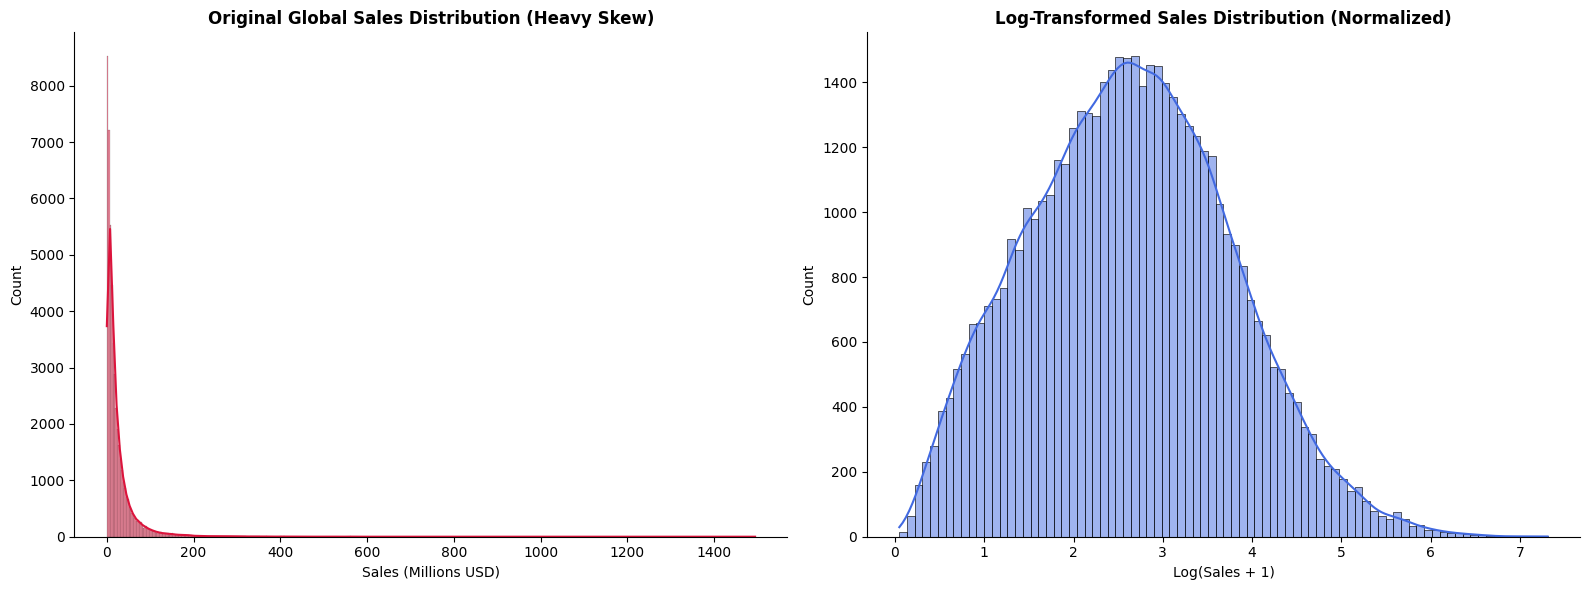

In [69]:

df["global_sales_log"] = np.log1p(df["global_sales_million"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["global_sales_million"], kde=True, ax=axes[0], color="crimson")
axes[0].set_title("Original Global Sales Distribution (Heavy Skew)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sales (Millions USD)")

sns.histplot(df["global_sales_log"], kde=True, ax=axes[1], color="royalblue")
axes[1].set_title("Log-Transformed Sales Distribution (Normalized)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Log(Sales + 1)")

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

> Challenge 24: Year-over-Year (YoY) Growth Metrics
We want to track the financial health of the gaming industry over time.

> Task: Calculate the total global sales for every year in the dataset. Then, create a window function to calculate the Year-over-Year (YoY) growth percentage in sales (e.g., how much did 2011 sales grow or shrink compared to 2010?).

> Hint: Look into .groupby() combined with the .pct_change() window method.

In [70]:
df.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'na_sales_million', 'eu_sales_million', 'jp_sales_million',
       'other_sales_million', 'global_sales_million',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'score_diff', 'era', 'hours_per_revenue', 'title_length',
       'publisher_encoded', 'global_sales_log'],
      dtype='object')

In [72]:
salesperyear = df.groupby("year")["global_sales_million"].sum()

yoy_growth = salesperyear.pct_change() * 100

yoy_report = pd.DataFrame({
    "Total_Sales_Millions": salesperyear,
    "YoY_Growth_Percent": yoy_growth
})

print(yoy_report)

      Total_Sales_Millions  YoY_Growth_Percent
year                                          
1985              18106.27                 NaN
1986              18630.19            2.893583
1987              18056.44           -3.079679
1988              17387.19           -3.706434
1989              17746.10            2.064221
1990              17152.72           -3.343721
1991              16972.96           -1.047997
1992              17022.28            0.290580
1993              17425.87            2.370951
1994              16919.36           -2.906655
1995              19416.57           14.759483
1996              19693.94            1.428522
1997              20797.88            5.605481
1998              20382.75           -1.996021
1999              21266.58            4.336167
2000              20692.71           -2.698459
2001              22104.95            6.824819
2002              21732.33           -1.685686
2003              23408.26            7.711690
2004         

> Challenge 25: The Running Cumulative Dominance
Let's see how genres built up their market dominance over history.

> Task: Create a new DataFrame that tracks the cumulative running total of global sales over time (ordered chronologically by year), broken down by genre.

> Hint: Look into the .cumsum() window function applied across grouped time elements.

In [73]:
newdf = df.sort_values('year').groupby('genre')['global_sales_million'].cumsum()


11324         4.68
9211         11.53
29223         4.34
29220        10.60
24192         4.78
           ...    
44352    208197.93
20039     23439.39
30583     16291.00
1273      62525.89
49955    169891.12
Name: global_sales_million, Length: 50000, dtype: float64

In [74]:
# 1. Sort the entire dataset chronologically first
df_sorted = df.sort_values(by="year").copy()

# 2. Calculate the cumulative total and assign it to a new column
df_sorted["cumulative_genre_sales"] = df_sorted.groupby("genre")["global_sales_million"].cumsum()

# 3. Keep a clean view of the tracking columns
genre_dominance = df_sorted[["year", "genre", "global_sales_million", "cumulative_genre_sales"]]

print(genre_dominance.tail(15))

       year          genre  global_sales_million  cumulative_genre_sales
22668  2026        Shooter                 29.59               169380.95
3948   2026      Adventure                 10.19                39900.59
37474  2026        Shooter                196.28               169577.23
25424  2026         Racing                 10.42                82745.33
49927  2026         Sports                 70.87               263699.95
15528  2026         Sports                138.88               263838.83
25382  2026       Fighting                  6.49                62515.57
37505  2026         MMORPG                  1.27                16289.06
15521  2026  Battle Royale                100.38                37460.91
49941  2026       Platform                  6.74                85004.80
44352  2026         Action                 37.04               208197.93
20039  2026       Strategy                 22.53                23439.39
30583  2026         MMORPG                  1.94   

In [75]:
# Create a historical timeline matrix of genre dominance
timeline_matrix = df_sorted.pivot_table(
    index="year", 
    columns="genre", 
    values="cumulative_genre_sales", 
    aggfunc="max" # Takes the highest cumulative total reached in that year
).ffill()         # Forward-fills any years where a genre didn't release a game

print(timeline_matrix.tail())

genre     Action  Action-Adventure  Adventure  Battle Royale  Fighting  \
year                                                                     
2022   175293.64          26330.84   32736.14       30074.97  49771.29   
2023   182402.24          27344.70   34624.16       31550.11  52240.68   
2024   190207.87          28907.77   36180.92       34230.45  54558.16   
2025   198197.53          30311.02   38009.55       36226.57  57951.06   
2026   208197.93          31859.39   39900.59       37460.91  62525.89   

genre  Idle/Clicker    MMORPG      Misc  Platform    Puzzle    Racing  \
year                                                                    
2022        4813.26  14087.21  21483.88  70895.64  22522.03  68863.15   
2023        5138.84  14811.07  22538.24  74227.80  23430.68  73201.96   
2024        5342.10  15240.38  23865.86  78361.36  24900.13  76631.28   
2025        5780.27  15718.57  24950.33  81096.98  26084.45  79736.09   
2026        6392.30  16291.00  25942.19  85

> Challenge 26: Finding the "Peak Era" via Rolling Windows
An industry trend can last a few years. Let's find the most lucrative 3-year consecutive window in gaming history.

> Task: Aggregate total global sales by year. Then, use a 3-year rolling window to find which consecutive 3-year block generated the highest average global sales.

> Hint: Investigate the .rolling(window=3) method.

In [77]:
df['3years'] = df.groupby('year')['global_sales_million'].rolling(window=3).sum().reset_index(level=0, drop=True)


In [80]:
# 1. Aggregate total sales by year to get a clean chronological timeline
yearly_sales = df.groupby("year")["global_sales_million"].sum().sort_index()

# 2. Calculate the 3-year rolling sum across consecutive years
# (e.g., Year 2010 value will be the sum of 2008 + 2009 + 2010)
rolling_3yr = yearly_sales.rolling(window=3).sum()

# 3. Combine them into a clear evaluation DataFrame
peak_era_df = pd.DataFrame({
    "Yearly_Sales": yearly_sales,
    "3_Year_Rolling_Total": rolling_3yr
})

# 4. Find the absolute highest 3-year window in history
peak_era = peak_era_df.sort_values(by="3_Year_Rolling_Total", ascending=False).head(1)
print(peak_era)

      Yearly_Sales  3_Year_Rolling_Total
year                                    
2026      61368.56              177697.4
